# H4 — Target amino-acid similarity networks

## Purpose
Turns the per-pair amino-acid similarity scores computed in [`amino_acid_sim_notebook.ipynb`](./amino_acid_sim_notebook.ipynb) into weighted, undirected `networkx` graphs suitable for node2vec embedding -- the same recipe `h1_biological_overlap`/`h3_structural_similarity` use, applied to the H4 feature type.

Edge weight = `similarity_score`, which `amino_acid_sim_notebook.ipynb` set to the winning kernel's `best_match_avg` (currently `kmer_cosine_best_match_avg` -- k-mer composition cosine similarity, symmetric-best-match-aggregated across each pair's two target-protein sets). See that notebook's Section 9 for why `kmer_cosine` was selected over the hashed-fingerprint and alignment kernels.

We build **two** graphs -- one over the curated *adverse* DDI pairs, one over the sampled *non-interacting* pairs -- plus a **combined** graph (union of both populations, label-agnostic) that `node2vec_embedding.ipynb` trains its canonical embedding on.

## Pipeline
1. Load the per-pair `similarity_score` and target-count columns.
2. Derive a per-drug size proxy (`n_targets`, pooled across both pair sides) for the size-leakage diagnostic.
3. Pivot each pair-list into a dense drug-by-drug similarity matrix.
4. Sparsify each dense matrix into a graph using [`src/network_builder.py`](../../src/network_builder.py) (hybrid top-k + minimum-similarity sparsification, same settings as H1/H3 for comparability).
5. Run the network diagnostics suite (edge-weight sanity, degree distribution, DDI-topology check).
6. Save both graphs to GraphML under `networks/`.
7. Build and save a third, combined graph (union of both populations) for node2vec.

## Key caveat -- read before trusting the diagnostics
Like H1/H3, these parquet files only contain the **specific pairs that were sampled**, not the full N-choose-2 universe of DrugBank pairs -- pivoting into a dense matrix fills every unsampled pair with `0.0`, conflating "never measured" with "measured and dissimilar". The diagnostics below describe how well amino-acid similarity separates *these specific* adverse vs. non-interacting samples, not a fully general drug-drug similarity space. See [`h3_structural_similarity/network_generation.ipynb`](../h3_structural_similarity/network_generation.ipynb) for the full glossary of terms used here (graph/node/edge, sparsification, Spearman rho, AUROC, etc.) -- not repeated in full below to avoid duplication.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

SRC_FOLDER = r"C:\Users\ashto\ddi-prediction\src"
if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)

from network_builder import build_sparsified_graph, edge_list_to_matrix, NetworkDiagnostics

H4_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h4_target_amino_acid_sim")
OUTPUT_DIR = H4_DIR / "networks"
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Load per-pair amino-acid similarity scores

`adverse_amino_acid_sim.parquet` / `non_interacting_amino_acid_sim.parquet` each have one row per drug pair with `drug1_id`, `drug2_id`, `drug1_name`, `drug2_name`, `n_targets_1`, `n_targets_2`, all six kernel metrics, and `similarity_score` -- the value used as edge weight below.


In [2]:
adverse_amino_acid_df = pd.read_parquet(H4_DIR / "adverse_amino_acid_sim.parquet")
non_interacting_amino_acid_df = pd.read_parquet(H4_DIR / "non_interacting_amino_acid_sim.parquet")

print(adverse_amino_acid_df.shape, non_interacting_amino_acid_df.shape)
adverse_amino_acid_df.head()


(471169, 13) (162788, 13)


,drug1_id,drug2_id,drug1_name,drug2_name,n_targets_1,n_targets_2,kmer_fp_mean_similarity,kmer_fp_max_similarity,kmer_fp_best_match_avg,kmer_cosine_mean_similarity,kmer_cosine_max_similarity,kmer_cosine_best_match_avg,similarity_score
0,DB00006,DB06605,Bivalirudin,Apixaban,1,1,0.208388,0.208388,0.208388,0.161692,0.161692,0.161692,0.161692
1,DB00006,DB06695,Bivalirudin,Dabigatran etexilate,1,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,DB00006,DB01254,Bivalirudin,Dasatinib,1,23,0.198479,0.243194,0.220837,0.108032,0.149992,0.129012,0.129012
3,DB00006,DB01609,Bivalirudin,Deferasirox,1,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,DB00006,DB01586,Bivalirudin,Ursodeoxycholic acid,1,4,0.158606,0.209190,0.183898,0.088321,0.108338,0.098330,0.098330


## 2. Derive per-drug size and name lookups

Diagnostic A needs a "profile size" per drug. For amino-acid similarity, the natural proxy is **the number of resolved target proteins** (`n_targets`) -- a drug with many targets has many chances at a high cross-similarity score, which could inflate `similarity_score` for reasons unrelated to genuine sequence homology. We pool `n_targets_1`/`n_targets_2` (and `drug1_name`/`drug2_name`) across both pair sides into one per-drug lookup.


In [3]:
def derive_amino_acid_size_vector(df):
    """drug_id -> resolved target count, pooled across both pair sides."""
    a = df[["drug1_id", "n_targets_1"]].rename(columns={"drug1_id": "id", "n_targets_1": "n_targets"})
    b = df[["drug2_id", "n_targets_2"]].rename(columns={"drug2_id": "id", "n_targets_2": "n_targets"})
    unique_drugs = pd.concat([a, b]).drop_duplicates("id")
    return unique_drugs.set_index("id")["n_targets"].to_dict()


def derive_name_lookup(df):
    """drug_id -> drug name, pooled across both pair sides."""
    names_a = df[["drug1_id", "drug1_name"]].rename(columns={"drug1_id": "id", "drug1_name": "name"})
    names_b = df[["drug2_id", "drug2_name"]].rename(columns={"drug2_id": "id", "drug2_name": "name"})
    return pd.concat([names_a, names_b]).drop_duplicates("id").set_index("id")["name"].to_dict()


## 3. Sparsification strategy

We use **`method="hybrid"`**: keep each drug's `K_NEIGHBORS` highest-similarity neighbors, but require `weight >= MIN_SIMILARITY`. Same settings as `h1_biological_overlap`/`h3_structural_similarity` for comparability across feature types -- rerun Section 4 after changing them.


In [4]:
K_NEIGHBORS = 15
MIN_SIMILARITY = 1e-9  # excludes true-zero "neighbors"; raise this to prune weak edges further


## 4. Build the dense matrices and sparsified graphs

Pivot each dataset's pair list into a dense drug-by-drug matrix with `edge_list_to_matrix`, sparsify it, then attach the drug-name node attribute so the GraphML files stay human-readable.


In [5]:
DATASETS = {"adverse": adverse_amino_acid_df, "non_interacting": non_interacting_amino_acid_df}

amino_acid_matrices = {}
amino_acid_graphs = {}
amino_acid_size_vectors = {}
for label, df in DATASETS.items():
    sim_df = edge_list_to_matrix(df, weight_col="similarity_score")
    G = build_sparsified_graph(sim_df, method="hybrid", k=K_NEIGHBORS, min_sim=MIN_SIMILARITY)
    nx.set_node_attributes(G, derive_name_lookup(df), "name")

    amino_acid_matrices[label] = sim_df
    amino_acid_graphs[label] = G
    amino_acid_size_vectors[label] = derive_amino_acid_size_vector(df)
    print(f"{label:<16}: {sim_df.shape[0]:>5} drugs, {G.number_of_edges():>7} edges kept, density={nx.density(G):.5f}")


adverse         :  1893 drugs,   20868 edges kept, density=0.01165
non_interacting :  1900 drugs,   23315 edges kept, density=0.01292


## 5. Diagnostics

- **Diagnostic A (edge weights):** Spearman rho between edge weight and drug-pair target-count metrics -- does a drug simply having more resolved targets predict a bigger similarity score, even when it shouldn't? (pass: rho ≈ 0).
- **Diagnostic B (degree distribution):** isolate count, 5th-percentile degree (pass: 0 isolates, p5 >= 5), and degree-vs-size slope (pass: flat).
- **Diagnostic C (DDI topology):** AUROC using edge weight to separate known adverse DDI pairs from random pairs (pass: AUROC > 0.5). Only makes sense for the **adverse** graph -- skipped (`NaN`) for non_interacting, which has no known-positive labels of its own.


In [6]:
ADVERSE_DDI_EDGES = list(zip(adverse_amino_acid_df["drug1_id"], adverse_amino_acid_df["drug2_id"]))

amino_acid_diag_objects = {}
diagnostic_rows = []
for label, G in amino_acid_graphs.items():
    diag = NetworkDiagnostics(
        graph=G,
        size_vector=amino_acid_size_vectors[label],
        ddi_edges=ADVERSE_DDI_EDGES if label == "adverse" else [],
        sim_df=amino_acid_matrices[label],
    )
    amino_acid_diag_objects[label] = diag
    result = diag.run_all(n_random=5000)
    diagnostic_rows.append({
        "dataset": label,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "isolate_count": result.get("isolate_count"),
        "p5_degree": result.get("p5_degree"),
        "rho_size_diff": result.get("size_rho_size_diff"),
        "degree_vs_size_slope": result.get("degree_vs_size_slope"),
        "auroc_ddi_prediction": result.get("auroc_ddi_prediction"),
    })

amino_acid_diagnostics_df = pd.DataFrame(diagnostic_rows)
amino_acid_diagnostics_df


,dataset,n_nodes,n_edges,isolate_count,p5_degree,rho_size_diff,degree_vs_size_slope,auroc_ddi_prediction
0,adverse,1893,20868,106,0.0,-0.054753,0.137302,0.969574
1,non_interacting,1900,23315,105,0.0,0.094267,0.239622,NaN


### 5a. Detail plots


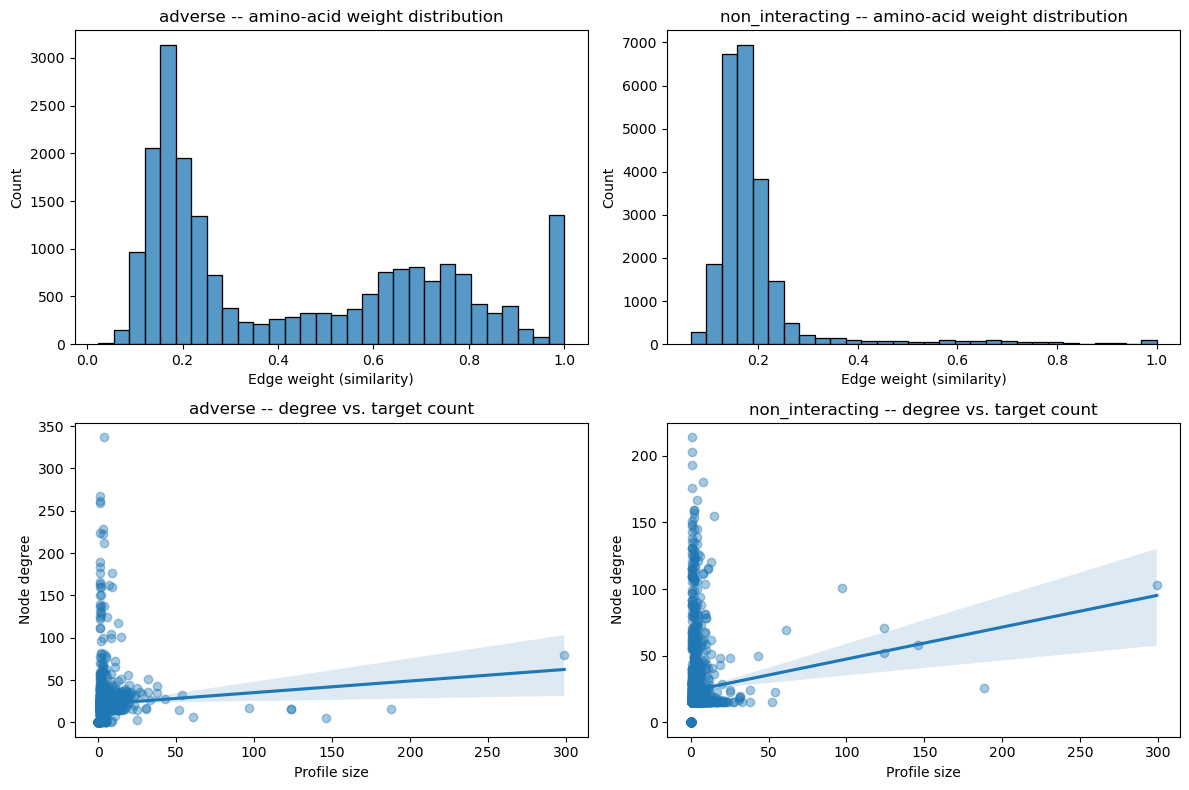

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, label in enumerate(["adverse", "non_interacting"]):
    diag = amino_acid_diag_objects[label]
    diag.plot_weight_distribution(ax=axes[0, col])
    axes[0, col].set_title(f"{label} -- amino-acid weight distribution")
    diag.degree_vs_size(plot=True, ax=axes[1, col])
    axes[1, col].set_title(f"{label} -- degree vs. target count")
plt.tight_layout()
plt.show()


## 6. Save graphs

Each graph is written to `networks/{dataset}_amino_acid.graphml`.


In [8]:
for label, G in amino_acid_graphs.items():
    nx.write_graphml(G, OUTPUT_DIR / f"{label}_amino_acid.graphml")

print(f"Saved {len(amino_acid_graphs)} graphs to {OUTPUT_DIR}")


Saved 2 graphs to C:\Users\ashto\ddi-prediction\notebooks\h4_target_amino_acid_sim\networks


## 7. Build the combined graph (for node2vec)

`node2vec_embedding.ipynb` needs a single, label-agnostic graph to train its canonical embedding on -- same reasoning as `h3_structural_similarity`'s Section 7. We build one graph from the union of both pair populations here, using the same sparsification settings as Section 4.


In [9]:
combined_amino_acid_df = pd.concat([adverse_amino_acid_df, non_interacting_amino_acid_df], ignore_index=True)

combined_sim_df = edge_list_to_matrix(combined_amino_acid_df, weight_col="similarity_score")
G_combined = build_sparsified_graph(combined_sim_df, method="hybrid", k=K_NEIGHBORS, min_sim=MIN_SIMILARITY)
nx.set_node_attributes(G_combined, derive_name_lookup(combined_amino_acid_df), "name")

n_isolates = sum(1 for _, deg in G_combined.degree() if deg == 0)
print(f"Combined graph: {G_combined.number_of_nodes():,} nodes, {G_combined.number_of_edges():,} edges, "
      f"{n_isolates} isolate(s), density={nx.density(G_combined):.5f}")

nx.write_graphml(G_combined, OUTPUT_DIR / "combined_amino_acid.graphml")
print(f"Saved to {OUTPUT_DIR / 'combined_amino_acid.graphml'}")


Combined graph: 1,900 nodes, 21,367 edges, 105 isolate(s), density=0.01184
Saved to C:\Users\ashto\ddi-prediction\notebooks\h4_target_amino_acid_sim\networks\combined_amino_acid.graphml


In [10]:
adverse_drugs = set(adverse_amino_acid_df["drug1_id"]) | set(adverse_amino_acid_df["drug2_id"])
non_interacting_drugs = set(non_interacting_amino_acid_df["drug1_id"]) | set(non_interacting_amino_acid_df["drug2_id"])
print(f"adverse unique drugs: {len(adverse_drugs)}")
print(f"non_interacting unique drugs: {len(non_interacting_drugs)}")
print(f"in both: {len(adverse_drugs & non_interacting_drugs)}")
print(f"only in adverse: {len(adverse_drugs - non_interacting_drugs)}")
print(f"only in non_interacting: {len(non_interacting_drugs - adverse_drugs)}")
print(f"union: {len(adverse_drugs | non_interacting_drugs)}")


adverse unique drugs: 1893
non_interacting unique drugs: 1900
in both: 1893
only in adverse: 0
only in non_interacting: 7
union: 1900


## Summary & limitations

**How to read `amino_acid_diagnostics_df`:**
- `isolate_count` should be 0 and `n_edges` should scale roughly with `n_nodes * K_NEIGHBORS / 2`.
- `rho_size_diff` / `degree_vs_size_slope` near 0 mean `similarity_score` isn't just an artifact of a drug having many resolved targets; a strong positive slope flags a graph where promiscuous drugs dominate connectivity.
- `auroc_ddi_prediction` (adverse row only) above 0.5 means amino-acid similarity helps separate known adverse DDI pairs from random pairs.

**Known limitations:**
1. The dense matrices are built only from the sampled adverse/non-interacting pairs (see the caveat at the top of this notebook) -- not the full drug universe.
2. `n_targets` is a coarse size proxy -- it doesn't distinguish "many weakly related targets" from "many strongly related targets."
3. `K_NEIGHBORS` / `MIN_SIMILARITY` were chosen to match H1/H3 for comparability, not tuned specifically for this feature type.
4. The combined graph (Section 7) isn't run through the same diagnostics suite as the two per-population graphs -- it's built purely as node2vec training input.
